# Comparison between: Rule-based vs ECMS vs DP

Same lap (Canada 2026 quali), same $SoC(0)=0.9$, same $E_{ES2K}(0)=0$.
Main Object: quantify how close rule-based approaches and ECMS come to the theoretical optimum calculated by DP.

- **Rule-based**: `controller/ruled_based.py` + `plant/powertrain.py` (the true, complete Willans model, 
not the approximation used by DP/ECMS).
- **ECMS**: same quadratic cost, for `s(k)` a proportional feedback in the trajectory of the SoC of DP.
- **DP**:results calculated and saved in the directory data

In [2]:
import numpy as np
import matplotlib.pyplot as plot
from plant.parameters import params
from plant.battery import battery_step, coef_quad, Uoc
from plant.powertrain import powertrain
from controller.ruled_based import rule_based_split


In [3]:
Delta_t = 0.1

Voc = params['V_oc_nom']
Q_bat = params['E_pack_capacity'] / Voc

P_MGU_max = params['P_MGU_max']
P_MGU_min = params['P_MGU_min']
P_eng_max = params['P_ICE_max']
E_ES2K_max = params['E_deploy_max']
SOC_min = params['SoC_min']
SOC_max = params['SoC_max']

eta_ICE = params['eta_ICE']
P_ICE0 = params['P_ICE0']
LHV = params['LHV']
m_dot_max = params['m_dot_max'] / 3600.0

Tbat = params['T_bat_init']

DATA_DIR = '/app/Thermal-Aware-Energy-Management-System-for-a-Hybrid-Motorsport-Powertrain/data'

# Same lap for all three methods
data = np.load(f'{DATA_DIR}/Canada_qualifying.npy')
t, v, a = data[0,:], data[1,:], data[2,:]

data_of_power_gb = np.load(f'{DATA_DIR}/power_domand.npy')
P_gb = data_of_power_gb[1,:]

N = len(t)

SOC_0 = 0.9
E_0 = 0.0


## 1.Load the DP results (already calculated)

In [4]:
SoC_dp = np.load(f'{DATA_DIR}/SOC_DP_Canada_qualifying.npy')
P_MGUK_dp = np.load(f'{DATA_DIR}/P_MGUK_DP_Canada_qualifying.npy')
J_dp = np.load(f'{DATA_DIR}/J_DP_Canada_qualifying.npy')
E_ES2K_dp = np.load(f'{DATA_DIR}/E_ES2K_DP_Canada_qualifying.npy')

fuel_dp = np.sum(J_dp) * 1e3  # g
print(f"fuel: {fuel_dp:.2f} g | final SoC: {SoC_dp[-2]:.4f} | deploy: {E_ES2K_dp[-2]/1e6:.3f} MJ")


fuel: 501.45 g | final SoC: 0.5912 | deploy: 9.000 MJ


## 2. Run a rule-based simulation on the same cycle.

Use `plant/powertrain.py` directly (full Willans line, not 
the DP/ECMS bound approximation) to remain faithful to the 
model the rule-based controller was designed to drive from the start.

In [5]:
def simulate_rule_based(SOC_0, E_0, P_gb, dt=Delta_t):
    N_local = len(P_gb)

    SoC_sim = np.zeros(N_local)
    E_ES2K_sim = np.zeros(N_local)
    E_recharge_sim = np.zeros(N_local)
    P_MGUK_sim = np.zeros(N_local)
    P_ICE_sim = np.zeros(N_local)
    m_dot_sim = np.zeros(N_local)
    J_sim = np.zeros(N_local)
    shortfall_sim = np.zeros(N_local)

    SoC_sim[0] = SOC_0
    E_ES2K_sim[0] = E_0

    for k in range(N_local - 1):
        u_split = rule_based_split(SoC_sim[k], P_gb[k], E_ES2K_sim[k], params)

        P_ICE_real, P2, P_mech_MGUK_real, shortfall, E_deploy_next, E_recharge_next = powertrain(
            P_gb[k], u_split, E_ES2K_sim[k], E_recharge_sim[k], params, dt
        )

        P_ICE_sim[k] = P_ICE_real
        P_MGUK_sim[k] = P2
        shortfall_sim[k] = max(shortfall, 0.0)  # negative shortfall in braking = brake-absorbed, not a real gap

        m_dot = (P_ICE_real + P_ICE0) / (eta_ICE * LHV)
        m_dot_sim[k] = np.clip(m_dot, 0.0, m_dot_max)
        J_sim[k] = m_dot_sim[k] * dt

        SoC_sim[k+1], _, _ = battery_step(SoC_sim[k], P2, coef_quad, Tbat, params, dt)
        E_ES2K_sim[k+1] = E_deploy_next
        E_recharge_sim[k+1] = E_recharge_next

    return P_MGUK_sim, P_ICE_sim, m_dot_sim, J_sim, SoC_sim, E_ES2K_sim, shortfall_sim


P_MGUK_rb, P_eng_rb, m_dot_rb, J_rb, SoC_rb, E_ES2K_rb, shortfall_rb = simulate_rule_based(SOC_0, E_0, P_gb)

fuel_rb = np.sum(J_rb) * 1e3
print(f"Rule-based -- fuel: {fuel_rb:.2f} g | final SoC: {SoC_rb[-2]:.4f} | deploy: {E_ES2K_rb[-2]/1e6:.3f} MJ")


Rule-based -- fuel: 754.41 g | final SoC: 0.8003 | deploy: 4.495 MJ


## 3. Simulate ECMS on the same lap.

Same functions already validated in `ECMS.ipynb`.

In [6]:
def ecms_bounds(P_gb_k, SoC_k, E_k, dt):
    Uoc_k = Uoc(SoC_k, coef_quad)
    soc_max_term = ((SOC_max - SoC_k) * Q_bat * Uoc_k) / -dt
    soc_min_term = ((SOC_min - SoC_k) * Q_bat * Uoc_k) / -dt
    E_deploy = (E_ES2K_max - E_k) / dt

    if P_gb_k >= 0:
        lb = max(soc_max_term, P_MGU_min, P_gb_k - P_eng_max)
        ub = min(soc_min_term, P_MGU_max, P_gb_k, E_deploy)
    else:
        lb = max(soc_max_term, P_MGU_min, P_gb_k)
        ub = min(soc_min_term, 0.0)
    return lb, ub


def ecms_step(P_gb_k, SoC_k, E_k, s, dt=Delta_t, n_grid=400):
    lb, ub = ecms_bounds(P_gb_k, SoC_k, E_k, dt)

    if ub < lb:
        P_mguk_opt = ub
        P_eng_req = P_gb_k - P_mguk_opt if P_gb_k >= 0 else 0.0
        m_dot_opt = np.clip((P_eng_req + P_ICE0) / (eta_ICE * LHV), 0.0, m_dot_max)
        P_eng_opt = m_dot_opt * eta_ICE * LHV - P_ICE0
        return P_mguk_opt, P_eng_opt, m_dot_opt

    P_mguk_grid = np.linspace(lb, ub, n_grid)

    if P_gb_k > 0:
        P_eng = np.clip(P_gb_k - P_mguk_grid, 0.0, P_eng_max)
    else:
        P_eng = np.zeros_like(P_mguk_grid)

    Uoc_k = Uoc(SoC_k, coef_quad)
    m_dot = np.clip((P_eng + P_ICE0) / (eta_ICE * LHV), 0.0, m_dot_max)
    R_int = params['R_int']
    J_eq = m_dot * dt + (s / LHV) * P_mguk_grid * dt + (1 / LHV) * (P_mguk_grid / Uoc_k) ** 2 * R_int * dt

    idx = np.argmin(J_eq)
    return P_mguk_grid[idx], P_eng[idx], m_dot[idx]


def simulate_ECMS(SOC_0, E_0, P_gb, SoC_ref, Kp, s_0=1.0, dt=Delta_t):
    N_local = len(P_gb)

    SoC_sim = np.zeros(N_local)
    E_ES2K_sim = np.zeros(N_local)
    P_MGUK_sim = np.zeros(N_local)
    P_eng_sim = np.zeros(N_local)
    m_dot_sim = np.zeros(N_local)
    J_sim = np.zeros(N_local)

    SoC_sim[0] = SOC_0
    E_ES2K_sim[0] = E_0

    for k in range(N_local - 1):
        s_k = max(s_0 - Kp * (SoC_sim[k] - SoC_ref[k]), 0.0)

        P_mguk_k, P_eng_k, m_dot_k = ecms_step(P_gb[k], SoC_sim[k], E_ES2K_sim[k], s_k, dt)

        P_MGUK_sim[k] = P_mguk_k
        P_eng_sim[k] = P_eng_k
        m_dot_sim[k] = m_dot_k
        J_sim[k] = m_dot_k * dt

        SoC_sim[k+1], _, _ = battery_step(SoC_sim[k], P_mguk_k, coef_quad, Tbat, params, dt)
        E_ES2K_sim[k+1] = E_ES2K_sim[k] + max(P_mguk_k, 0.0) * dt

    return P_MGUK_sim, P_eng_sim, m_dot_sim, J_sim, SoC_sim, E_ES2K_sim


Kp = 170
P_MGUK_ecms, P_eng_ecms, m_dot_ecms, J_ecms, SoC_ecms, E_ES2K_ecms = simulate_ECMS(
    SOC_0, E_0, P_gb, SoC_dp, Kp
)

fuel_ecms = np.sum(J_ecms) * 1e3
print(f"ECMS -- fuel: {fuel_ecms:.2f} g | final SoC: {SoC_ecms[-2]:.4f} | deploy: {E_ES2K_ecms[-2]/1e6:.3f} MJ")


ECMS -- fuel: 501.28 g | final SoC: 0.5951 | deploy: 9.000 MJ


## 4. Summary table

In [7]:
pct_rb = (fuel_rb - fuel_dp) / fuel_dp * 100
pct_ecms = (fuel_ecms - fuel_dp) / fuel_dp * 100

print(f"{'Method':<15}{'Fuel [g]':>12}{'SoC finale':>14}{'Deploy [MJ]':>14}{'% vs DP':>12}")
print("-" * 67)
print(f"{'DP (optimal)':<15}{fuel_dp:>12.2f}{SoC_dp[-2]:>14.4f}{E_ES2K_dp[-2]/1e6:>14.3f}{'--':>12}")
print(f"{'ECMS':<15}{fuel_ecms:>12.2f}{SoC_ecms[-2]:>14.4f}{E_ES2K_ecms[-2]/1e6:>14.3f}{pct_ecms:>11.2f}%")
print(f"{'Rule-based':<15}{fuel_rb:>12.2f}{SoC_rb[-2]:>14.4f}{E_ES2K_rb[-2]/1e6:>14.3f}{pct_rb:>11.2f}%")


Method             Fuel [g]    SoC finale   Deploy [MJ]     % vs DP
-------------------------------------------------------------------
DP (optimal)         501.45        0.5912         9.000          --
ECMS                 501.28        0.5951         9.000      -0.03%
Rule-based           754.41        0.8003         4.495      50.45%


## 5. Overlaid graphs

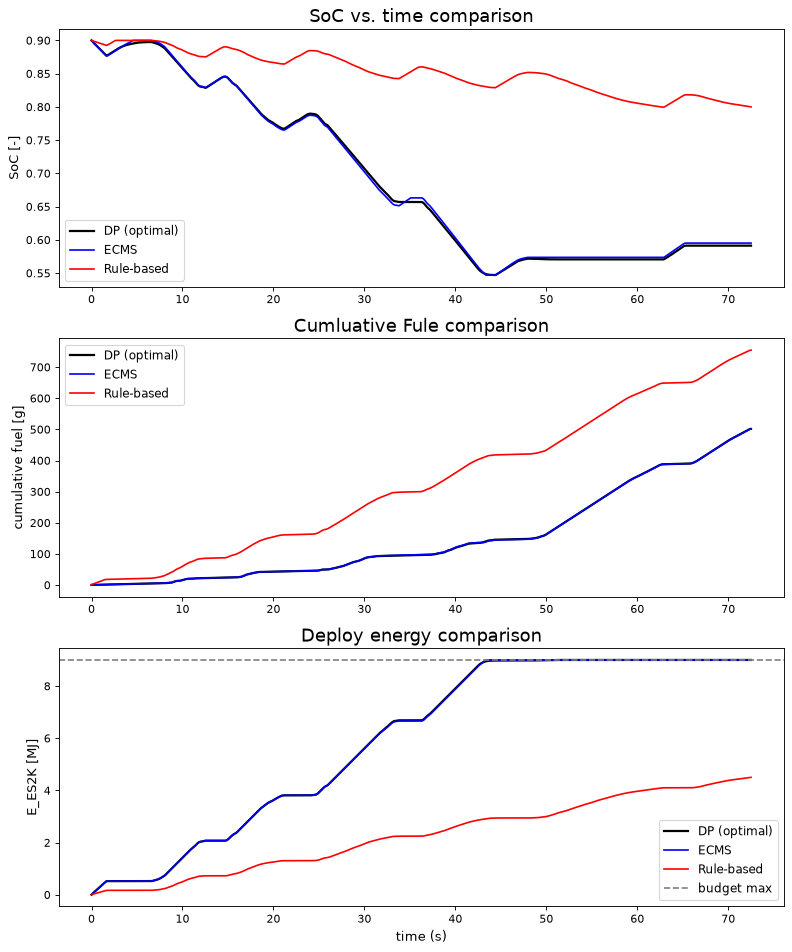

In [9]:
plot.figure(figsize=(10, 12), dpi=80, facecolor='w')

plot.subplot(3,1,1)
plot.plot(t, SoC_dp, 'k', label='DP (optimal)', linewidth=2)
plot.plot(t, SoC_ecms, 'b', label='ECMS')
plot.plot(t, SoC_rb, 'r', label='Rule-based')
plot.ylabel('SoC [-]', fontsize=12)
plot.title('SoC vs. time comparison', fontsize=16)
plot.legend(fontsize=11)

plot.subplot(3,1,2)
plot.plot(t, np.cumsum(J_dp)*1e3, 'k', label='DP (optimal)', linewidth=2)
plot.plot(t, np.cumsum(J_ecms)*1e3, 'b', label='ECMS')
plot.plot(t, np.cumsum(J_rb)*1e3, 'r', label='Rule-based')
plot.ylabel('cumulative fuel [g]', fontsize=12)
plot.title('Cumluative Fule comparison', fontsize=16)
plot.legend(fontsize=11)

plot.subplot(3,1,3)
plot.plot(t, E_ES2K_dp/1e6, 'k', label='DP (optimal)', linewidth=2)
plot.plot(t, E_ES2K_ecms/1e6, 'b', label='ECMS')
plot.plot(t, E_ES2K_rb/1e6, 'r', label='Rule-based')
plot.axhline(E_ES2K_max/1e6, color='gray', linestyle='--', label='budget max')
plot.ylabel('E_ES2K [MJ]', fontsize=12)
plot.xlabel('time (s)', fontsize=12)
plot.title('Deploy energy comparison', fontsize=16)
plot.legend(fontsize=11)

plot.tight_layout()
plot.show()
